# S3Eval: Paper Figures & Analysis

Generate figures for the workshop paper.


In [1]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 9

RESULTS_BASE = os.path.join('..', '..', 'results', 'tests', 'reference_set')
INTR_LLM = os.path.join(RESULTS_BASE, 'semantic', 'intrinsic', 'llm-as-experts')
EXTR_LLM = os.path.join(RESULTS_BASE, 'semantic', 'extrinsic', 'llm-as-experts')
INTR_EMB = os.path.join(RESULTS_BASE, 'semantic', 'intrinsic', 'similarity')
EXTR_EMB = os.path.join(RESULTS_BASE, 'semantic', 'extrinsic', 'similarity')
FIG_DIR = os.path.join('..', '..', 'Fig')
os.makedirs(FIG_DIR, exist_ok=True)
print('Paths OK')


Paths OK


In [2]:
def compute_f1(fpath, label_key='label'):
    """Compute F1, precision, recall, accuracy from results jsonl."""
    ref_true = ref_false = bad_true = bad_false = ref_none = bad_none = 0
    if not os.path.exists(fpath):
        return None
    with open(fpath) as f:
        for line in f:
            if not line.strip(): continue
            r = json.loads(line)
            source = r.get('source', '')
            label = r.get(label_key)
            if source == 'reference':
                if label is True: ref_true += 1
                elif label is False: ref_false += 1
                else: ref_none += 1
            elif source == 'bad':
                if label is True: bad_true += 1
                elif label is False: bad_false += 1
                else: bad_none += 1
    total_ref = ref_true + ref_false + ref_none
    total_bad = bad_true + bad_false + bad_none
    if total_ref + total_bad == 0: return None
    tp, fn, fp, tn = ref_true, ref_false + ref_none, bad_true, bad_false
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    acc = (tp+tn)/(total_ref+total_bad)
    return {'f1': f1, 'prec': prec, 'rec': rec, 'acc': acc, 'tp': tp, 'fn': fn, 'fp': fp, 'tn': tn,
            'ref_total': total_ref, 'bad_total': total_bad}

print('Helper loaded')


Helper loaded


In [3]:
# ── Collect all LLM results ──
llm_models = {
    # Local models (binary = simplified, scored = detailed)
    'Qwen3-4B': 'qwen3:4b-fp16',
    'Qwen3-8B': 'qwen3:8b-fp16',
    'Qwen3-14B': 'qwen3:14b',
    'Qwen3-32B': 'qwen3:32b',
    # Online models
    'GPT-4.1': 'gpt-4.1',
    'GPT-5.4': 'gpt-5.4',
    'GPT-5.5': 'gpt-5.5',
    'DS-R1': 'deepseek-reasoner',
}

results = {}
for display_name, model_id in llm_models.items():
    results[display_name] = {}
    for setting, base in [('intr', INTR_LLM), ('extr', EXTR_LLM)]:
        for mode, lkey in [('binary', 'label'), ('scored', 'verdict')]:
            fname = f'results_{"intrinsic" if setting=="intr" else "extrinsic"}_{mode}_{model_id}.jsonl'
            fpath = os.path.join(base, fname)
            r = compute_f1(fpath, lkey)
            key = f'{setting}_{mode}'
            results[display_name][key] = r
            if r:
                print(f'{display_name:15} {key:15} F1={r["f1"]:.3f} Ref={r["tp"]}/{r["ref_total"]} Bad={r["tn"]}/{r["bad_total"]}')
            else:
                print(f'{display_name:15} {key:15} NO DATA')


Qwen3-4B        intr_binary     F1=0.693 Ref=52/55 Bad=12/55
Qwen3-4B        intr_scored     F1=0.711 Ref=54/55 Bad=12/55
Qwen3-4B        extr_binary     F1=0.739 Ref=51/55 Bad=23/55
Qwen3-4B        extr_scored     F1=0.734 Ref=51/55 Bad=22/55
Qwen3-8B        intr_binary     F1=0.702 Ref=53/55 Bad=12/55
Qwen3-8B        intr_scored     F1=0.715 Ref=49/55 Bad=22/55
Qwen3-8B        extr_binary     F1=0.766 Ref=54/55 Bad=23/55
Qwen3-8B        extr_scored     F1=0.777 Ref=54/55 Bad=25/55
Qwen3-14B       intr_binary     F1=0.693 Ref=53/55 Bad=10/55
Qwen3-14B       intr_scored     F1=0.730 Ref=54/55 Bad=16/55
Qwen3-14B       extr_binary     F1=0.794 Ref=54/55 Bad=28/55
Qwen3-14B       extr_scored     F1=0.780 Ref=55/55 Bad=24/55
Qwen3-32B       intr_binary     F1=0.643 Ref=45/55 Bad=15/55
Qwen3-32B       intr_scored     F1=0.733 Ref=44/47 Bad=19/48
Qwen3-32B       extr_binary     F1=1.000 Ref=14/14 Bad=0/0
Qwen3-32B       extr_scored     NO DATA
GPT-4.1         intr_binary     F1=0.701 Ref=54

## Syntax & Solvability Metrics

In [4]:
# ── Syntax: TPR, FPR, F1 ──
syntax_path = os.path.join(RESULTS_BASE, 'syntax', 'results_syntax.jsonl')
tp = fn = fp = tn = 0
with open(syntax_path) as f:
    for line in f:
        if not line.strip(): continue
        d = json.loads(line)
        source, val = d.get('source', ''), d.get('syntax_ok', False)
        if source == 'reference':
            if val: tp += 1
            else: fn += 1
        elif source == 'bad':
            if val: fp += 1
            else: tn += 1

prec = tp / (tp + fp) if (tp + fp) else 0
rec = tp / (tp + fn) if (tp + fn) else 0
f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
tpr = rec
fpr = fp / (fp + tn) if (fp + tn) else 0

print(f"=== Syntax Check ===")
print(f"  TP={tp}  FN={fn}  FP={fp}  TN={tn}  (ref={tp+fn}, bad={fp+tn})")
print(f"  TPR={tpr:.3f}  FPR={fpr:.3f}  F1={f1:.3f}  Precision={prec:.3f}")

=== Syntax Check ===
  TP=52  FN=3  FP=47  TN=8  (ref=55, bad=55)
  TPR=0.945  FPR=0.855  F1=0.675  Precision=0.525


In [5]:
# ── Solvability: TPR, FPR, F1 ──
solv_path = os.path.join(RESULTS_BASE, 'solvability', 'results_solvability.jsonl')
tp = fn = fp = tn = 0
with open(solv_path) as f:
    for line in f:
        if not line.strip(): continue
        d = json.loads(line)
        source, val = d.get('source', ''), d.get('solvable', False)
        if source == 'reference':
            if val: tp += 1
            else: fn += 1
        elif source == 'bad':
            if val: fp += 1
            else: tn += 1

prec = tp / (tp + fp) if (tp + fp) else 0
rec = tp / (tp + fn) if (tp + fn) else 0
f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
tpr = rec
fpr = fp / (fp + tn) if (fp + tn) else 0

print(f"=== Solvability Check ===")
print(f"  TP={tp}  FN={fn}  FP={fp}  TN={tn}  (ref={tp+fn}, bad={fp+tn})")
print(f"  TPR={tpr:.3f}  FPR={fpr:.3f}  F1={f1:.3f}  Precision={prec:.3f}")

=== Solvability Check ===
  TP=55  FN=0  FP=47  TN=8  (ref=55, bad=55)
  TPR=1.000  FPR=0.855  F1=0.701  Precision=0.539


## RQ1: F1 Bar Chart (2×2 panels)


### Embedding-based Similarity F1


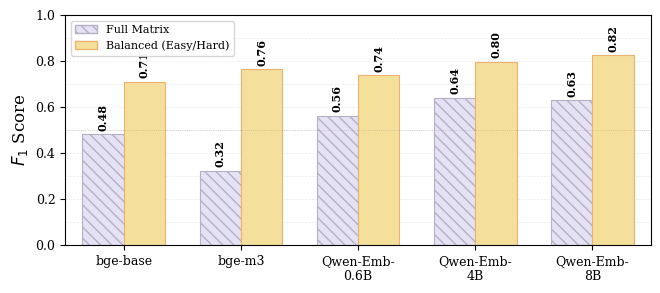

figsize=(6.68, 3)
Saved to Fig/rq1_emb_f1_intrinsic.png


In [90]:
# ── Embedding-based Similarity F1: Intrinsic ──
from matplotlib.patches import Patch

COLORS = {
    'red': (163/255, 81/255, 57/255),
    'dark_purple': (182/255, 175/255, 197/255),
    'dark_cyan': (182/255, 207/255, 212/255),
    'cyan': (225/255, 241/255, 246/255),
    'purple': (230/255, 226/255, 245/255),
    'orange': (244/255, 224/255, 155/255),
    'dark_orange': (234/255, 177/255, 112/255),
    'pink_red': (221/255, 185/255, 172/255),
}

emb_models = ['bge-base', 'bge-m3', 'Qwen-Emb-0.6B', 'Qwen-Emb-4B', 'Qwen-Emb-8B']
emb_labels = ['bge-base', 'bge-m3', 'Qwen-Emb-\n0.6B', 'Qwen-Emb-\n4B', 'Qwen-Emb-\n8B']

# Load intrinsic
emb_cv_path = os.path.join(INTR_EMB, 'cv_intrinsic_similarity.jsonl')
emb_intr = {}
if os.path.exists(emb_cv_path):
    with open(emb_cv_path) as f:
        for line in f:
            if not line.strip(): continue
            r = json.loads(line)
            model, method, f1 = r.get('model',''), r.get('cv_method',''), r.get('f1',0)
            key = None
            if 'bge-base' in model: key = 'bge-base'
            elif 'bge-m3' in model: key = 'bge-m3'
            elif 'Qwen3-Embedding-0.6B' in model: key = 'Qwen-Emb-0.6B'
            elif 'Qwen3-Embedding-4B' in model: key = 'Qwen-Emb-4B'
            elif 'Qwen3-Embedding-8B' in model: key = 'Qwen-Emb-8B'
            if key:
                if key not in emb_intr: emb_intr[key] = {}
                emb_intr[key][method] = f1

# Styles
style_full = {'fc': COLORS['purple'], 'ec': COLORS['dark_purple'], 'h': '\\\\\\', 'label': 'Full Matrix'}
style_bal = {'fc': COLORS['orange'], 'ec': COLORS['dark_orange'], 'h': '', 'label': 'Balanced (Easy/Hard)'}

# ── Absolute sizing (data coords + fixed scale) ──
BAR_WIDTH = 0.5
GROUP_GAP = 0.42
SCALE = 0.8
FIG_H = 3
FONT_SIZE_TICK = 12
TICK_LABEL_SIZE = 9

n = len(emb_models)
intr_step = 2 * BAR_WIDTH + GROUP_GAP
x = np.arange(n) * intr_step

x_pad = GROUP_GAP / 2
xlim = (x[0] - BAR_WIDTH - x_pad, x[-1] + BAR_WIDTH + x_pad)
data_w = xlim[1] - xlim[0]
fig_w = data_w * SCALE + 1.0

fig, ax = plt.subplots(figsize=(fig_w, FIG_H))

full_vals = [emb_intr.get(m, {}).get('reference_full_matrix', 0) for m in emb_models]
bal_vals = [emb_intr.get(m, {}).get('control_hardeasy_bad_ratio', 0) for m in emb_models]

bars1 = ax.bar(x - BAR_WIDTH/2, full_vals, BAR_WIDTH,
               color=style_full['fc'], edgecolor=style_full['ec'],
               hatch=style_full['h'], linewidth=0.8, zorder=2)
bars2 = ax.bar(x + BAR_WIDTH/2, bal_vals, BAR_WIDTH,
               color=style_bal['fc'], edgecolor=style_bal['ec'],
               hatch=style_bal['h'], linewidth=0.8, zorder=2)

for bar, val in zip(bars1, full_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')
for bar, val in zip(bars2, bal_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')

ax.set_xlim(xlim)
ax.set_xticks(x)
ax.set_xticklabels(emb_labels, rotation=0, ha='center', fontsize=TICK_LABEL_SIZE)
ax.set_ylabel('$F_1$ Score', fontsize=FONT_SIZE_TICK)
ax.set_ylim(0, 1.0)
ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
for y in np.arange(0, 1.1, 0.1):
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.15, zorder=0)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=style_full['fc'], edgecolor=style_full['ec'], hatch=style_full['h'], label=style_full['label']),
    Patch(facecolor=style_bal['fc'], edgecolor=style_bal['ec'], hatch=style_bal['h'], label=style_bal['label']),
]
ax.legend(handles=legend_elements, loc='upper left', ncol=1, fontsize=8,
          frameon=True, edgecolor='lightgray', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rq1_emb_f1_intrinsic.png'), dpi=600, bbox_inches='tight')
plt.show()
print(f'figsize=({fig_w:.2f}, {FIG_H})')
print('Saved to Fig/rq1_emb_f1_intrinsic.png')

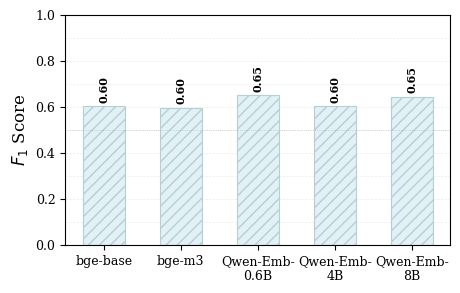

figsize=(4.68, 3)
Saved to Fig/rq1_emb_f1_extrinsic.png


In [104]:
# ── Embedding-based Similarity F1: Extrinsic ──

emb_models = ['bge-base', 'bge-m3', 'Qwen-Emb-0.6B', 'Qwen-Emb-4B', 'Qwen-Emb-8B']
emb_labels = ['bge-base', 'bge-m3', 'Qwen-Emb-\n0.6B', 'Qwen-Emb-\n4B', 'Qwen-Emb-\n8B']

# Load extrinsic
emb_extr_path = os.path.join(EXTR_EMB, 'cv_extrinsic_similarity.jsonl')
emb_extr = {}
if os.path.exists(emb_extr_path):
    with open(emb_extr_path) as f:
        for line in f:
            if not line.strip(): continue
            r = json.loads(line)
            model, f1 = r.get('model',''), r.get('f1',0)
            key = None
            if 'bge-base' in model: key = 'bge-base'
            elif 'bge-m3' in model: key = 'bge-m3'
            elif 'Qwen3-Embedding-0.6B' in model: key = 'Qwen-Emb-0.6B'
            elif 'Qwen3-Embedding-4B' in model: key = 'Qwen-Emb-4B'
            elif 'Qwen3-Embedding-8B' in model: key = 'Qwen-Emb-8B'
            if key:
                emb_extr[key] = f1

style_ext = {'fc': COLORS['cyan'], 'ec': COLORS['dark_cyan'], 'h': '///', 'label': 'Extrinsic'}

# ── Same absolute sizing constants as intrinsic ──
BAR_WIDTH = 0.5
GROUP_GAP = 0.42
SCALE = 0.8
FIG_H = 3
FONT_SIZE_TICK = 12
TICK_LABEL_SIZE = 9

n = len(emb_models)
extr_step = BAR_WIDTH + GROUP_GAP
x = np.arange(n) * extr_step

x_pad = GROUP_GAP / 2
xlim = (x[0] - BAR_WIDTH/2 - x_pad, x[-1] + BAR_WIDTH/2 + x_pad)
data_w = xlim[1] - xlim[0]
fig_w = data_w * SCALE + 1.0

fig, ax = plt.subplots(figsize=(fig_w, FIG_H))

extr_vals = [emb_extr.get(m, 0) for m in emb_models]

bars = ax.bar(x, extr_vals, BAR_WIDTH,
              color=style_ext['fc'], edgecolor=style_ext['ec'],
              hatch=style_ext['h'], linewidth=0.8, zorder=2)

for bar, val in zip(bars, extr_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')

ax.set_xlim(xlim)
ax.set_xticks(x)
ax.set_xticklabels(emb_labels, rotation=0, ha='center', fontsize=TICK_LABEL_SIZE)
ax.set_ylabel('$F_1$ Score', fontsize=FONT_SIZE_TICK)
ax.set_ylim(0, 1.0)
ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
for y in np.arange(0, 1.1, 0.1):
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.15, zorder=0)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=0.6, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rq1_emb_f1_extrinsic.png'), dpi=600, bbox_inches='tight')
plt.show()
print(f'figsize=({fig_w:.2f}, {FIG_H})')
print('Saved to Fig/rq1_emb_f1_extrinsic.png')

### LLM-as-Expert F1 + Cost (2 panels: Intrinsic / Extrinsic)

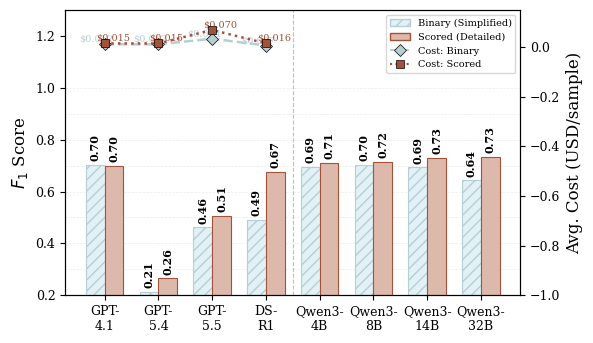

Saved to Fig/rq1_llm_f1_intrinsic.png


In [107]:
# ── RQ1: LLM-as-Expert F1 + Cost — Intrinsic ──
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

COLORS = {
    'red': (163/255, 81/255, 57/255),
    'dark_pink': (202/255, 162/255, 173/255),
    'dark_orange': (234/255, 177/255, 112/255),
    'dark_purple': (182/255, 175/255, 197/255),
    'dark_cyan': (182/255, 207/255, 212/255),
    'cyan': (225/255, 241/255, 246/255),
    'purple': (230/255, 226/255, 245/255),
    'orange': (244/255, 224/255, 155/255),
    'pink': (246/255, 223/255, 224/255),
    'pink_red': (221/255, 185/255, 172/255),
}

model_order = ['GPT-4.1', 'GPT-5.4', 'GPT-5.5', 'DS-R1', 'Qwen3-4B', 'Qwen3-8B', 'Qwen3-14B', 'Qwen3-32B']
model_labels = ['GPT-\n4.1', 'GPT-\n5.4', 'GPT-\n5.5', 'DS-\nR1', 'Qwen3-\n4B', 'Qwen3-\n8B', 'Qwen3-\n14B', 'Qwen3-\n32B']

# Cost per sample (USD) — computed from actual token usage × API pricing
model_costs_binary = {
    'GPT-4.1': 0.011638, 'GPT-5.4': 0.011611, 'GPT-5.5': 0.034182, 'DS-R1': 0.006766,
    'Qwen3-4B': 0.0, 'Qwen3-8B': 0.0, 'Qwen3-14B': 0.0, 'Qwen3-32B': 0.0,
}
model_costs_scored = {
    'GPT-4.1': 0.015130, 'GPT-5.4': 0.015096, 'GPT-5.5': 0.069569, 'DS-R1': 0.015746,
    'Qwen3-4B': 0.0, 'Qwen3-8B': 0.0, 'Qwen3-14B': 0.0, 'Qwen3-32B': 0.0,
}

bar_styles = {
    'binary': {'facecolor': COLORS['cyan'], 'edgecolor': COLORS['dark_cyan'], 'hatch': '///', 'label': 'Binary (Simplified)'},
    'scored': {'facecolor': COLORS['pink_red'], 'edgecolor': COLORS['red'], 'hatch': '', 'label': 'Scored (Detailed)'},
}

FONT_SIZE_TICK = 12
TICK_LABEL_SIZE = 9
BAR_WIDTH = 0.35
FIG_H = 3.5

fig, ax = plt.subplots(figsize=(6, FIG_H))
ax_c = ax.twinx()

x = np.arange(len(model_order))
setting = 'intr'

binary_vals = [results.get(m, {}).get(f'{setting}_binary', {}) for m in model_order]
scored_vals = [results.get(m, {}).get(f'{setting}_scored', {}) for m in model_order]
binary_vals = [r['f1'] if r else 0 for r in binary_vals]
scored_vals = [r['f1'] if r else 0 for r in scored_vals]

bs = bar_styles['binary']
bars1 = ax.bar(x - BAR_WIDTH/2, binary_vals, BAR_WIDTH,
               color=bs['facecolor'], edgecolor=bs['edgecolor'],
               hatch=bs['hatch'], linewidth=0.8, zorder=2)

ss = bar_styles['scored']
bars2 = ax.bar(x + BAR_WIDTH/2, scored_vals, BAR_WIDTH,
               color=ss['facecolor'], edgecolor=ss['edgecolor'],
               hatch=ss['hatch'], linewidth=0.8, zorder=2)

for bar, val in zip(bars1, binary_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')
for bar, val in zip(bars2, scored_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')

# Cost lines (only commercial models) — binary: dashed, scored: dotted
costs_bin = [model_costs_binary.get(m, 0) for m in model_order]
costs_sco = [model_costs_scored.get(m, 0) for m in model_order]
x_cost_bin = [xi for xi, c in zip(x, costs_bin) if c > 0]
c_cost_bin = [c for c in costs_bin if c > 0]
x_cost_sco = [xi for xi, c in zip(x, costs_sco) if c > 0]
c_cost_sco = [c for c in costs_sco if c > 0]

ax_c.plot(x_cost_bin, c_cost_bin, color=COLORS['dark_cyan'], marker='D', markersize=6,
          linewidth=1.8, linestyle='--', zorder=5, markeredgecolor='black', markeredgewidth=0.5)
ax_c.plot(x_cost_sco, c_cost_sco, color=COLORS['red'], marker='s', markersize=6,
          linewidth=1.8, linestyle=':', zorder=5, markeredgecolor='black', markeredgewidth=0.5)

for xi, c_b, c_s in zip(x_cost_bin, c_cost_bin, c_cost_sco):
    ax_c.text(xi - 0.15, c_b + 0.002, f'${c_b:.3f}', ha='center', va='bottom', fontsize=7, color=COLORS['dark_cyan'])
    ax_c.text(xi + 0.15, c_s + 0.002, f'${c_s:.3f}', ha='center', va='bottom', fontsize=7, color=COLORS['red'])

ax_c.set_ylim(-1, 0.15)
ax_c.tick_params(axis='y', labelsize=TICK_LABEL_SIZE, colors='black')
ax_c.spines['right'].set_color('black')
ax_c.set_ylabel('Avg. Cost (USD/sample)', fontsize=FONT_SIZE_TICK, color='black')

ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
for y in np.arange(0, 1.1, 0.1):
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.15, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=0, ha='center', fontsize=TICK_LABEL_SIZE)
ax.set_ylabel('$F_1$ Score', fontsize=FONT_SIZE_TICK)
ax.set_ylim(0.2, 1.3)
ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=bs['facecolor'], edgecolor=bs['edgecolor'], hatch=bs['hatch'], label='Binary (Simplified)'),
    Patch(facecolor=ss['facecolor'], edgecolor=ss['edgecolor'], hatch=ss['hatch'], label='Scored (Detailed)'),
    Line2D([0], [0], color=COLORS['dark_cyan'], marker='D', markersize=6, linestyle='--',
           markeredgecolor='black', markeredgewidth=0.5, label='Cost: Binary'),
    Line2D([0], [0], color=COLORS['red'], marker='s', markersize=6, linestyle=':',
           markeredgecolor='black', markeredgewidth=0.5, label='Cost: Scored'),
]
ax.legend(handles=legend_elements, loc='upper right', ncol=1, fontsize=7,
          frameon=True, edgecolor='lightgray', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rq1_llm_f1_intrinsic.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved to Fig/rq1_llm_f1_intrinsic.png')

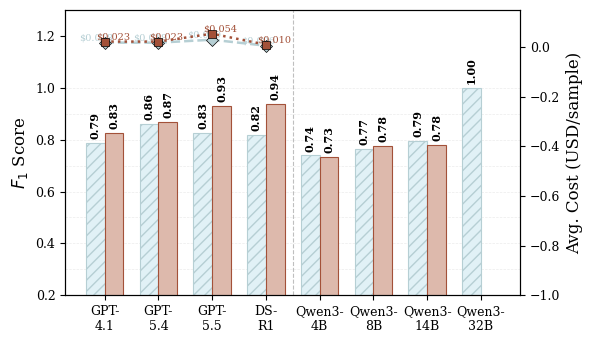

Saved to Fig/rq1_llm_f1_extrinsic.png


In [108]:
# ── RQ1: LLM-as-Expert F1 + Cost — Extrinsic ──

# Cost per sample (USD) — extrinsic
model_costs_binary_ext = {
    'GPT-4.1': 0.018428, 'GPT-5.4': 0.018418, 'GPT-5.5': 0.030220, 'DS-R1': 0.006019,
    'Qwen3-4B': 0.0, 'Qwen3-8B': 0.0, 'Qwen3-14B': 0.0, 'Qwen3-32B': 0.0,
}
model_costs_scored_ext = {
    'GPT-4.1': 0.022779, 'GPT-5.4': 0.022668, 'GPT-5.5': 0.054439, 'DS-R1': 0.010279,
    'Qwen3-4B': 0.0, 'Qwen3-8B': 0.0, 'Qwen3-14B': 0.0, 'Qwen3-32B': 0.0,
}

fig, ax = plt.subplots(figsize=(6, FIG_H))
ax_c = ax.twinx()

x = np.arange(len(model_order))
setting = 'extr'

binary_vals = [results.get(m, {}).get(f'{setting}_binary', {}) for m in model_order]
scored_vals = [results.get(m, {}).get(f'{setting}_scored', {}) for m in model_order]
binary_vals = [r['f1'] if r else 0 for r in binary_vals]
scored_vals = [r['f1'] if r else 0 for r in scored_vals]

bs = bar_styles['binary']
bars1 = ax.bar(x - BAR_WIDTH/2, binary_vals, BAR_WIDTH,
               color=bs['facecolor'], edgecolor=bs['edgecolor'],
               hatch=bs['hatch'], linewidth=0.8, zorder=2)

ss = bar_styles['scored']
bars2 = ax.bar(x + BAR_WIDTH/2, scored_vals, BAR_WIDTH,
               color=ss['facecolor'], edgecolor=ss['edgecolor'],
               hatch=ss['hatch'], linewidth=0.8, zorder=2)

for bar, val in zip(bars1, binary_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')
for bar, val in zip(bars2, scored_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.015,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')

# Cost lines (only commercial models) — binary: dashed, scored: dotted
costs_bin = [model_costs_binary_ext.get(m, 0) for m in model_order]
costs_sco = [model_costs_scored_ext.get(m, 0) for m in model_order]
x_cost_bin = [xi for xi, c in zip(x, costs_bin) if c > 0]
c_cost_bin = [c for c in costs_bin if c > 0]
x_cost_sco = [xi for xi, c in zip(x, costs_sco) if c > 0]
c_cost_sco = [c for c in costs_sco if c > 0]

ax_c.plot(x_cost_bin, c_cost_bin, color=COLORS['dark_cyan'], marker='D', markersize=6,
          linewidth=1.8, linestyle='--', zorder=5, markeredgecolor='black', markeredgewidth=0.5)
ax_c.plot(x_cost_sco, c_cost_sco, color=COLORS['red'], marker='s', markersize=6,
          linewidth=1.8, linestyle=':', zorder=5, markeredgecolor='black', markeredgewidth=0.5)

for xi, c_b, c_s in zip(x_cost_bin, c_cost_bin, c_cost_sco):
    ax_c.text(xi - 0.15, c_b + 0.002, f'${c_b:.3f}', ha='center', va='bottom', fontsize=7, color=COLORS['dark_cyan'])
    ax_c.text(xi + 0.15, c_s + 0.002, f'${c_s:.3f}', ha='center', va='bottom', fontsize=7, color=COLORS['red'])

ax_c.set_ylim(-1, 0.15)
ax_c.tick_params(axis='y', labelsize=TICK_LABEL_SIZE, colors='black')
ax_c.spines['right'].set_color('black')
ax_c.set_ylabel('Avg. Cost (USD/sample)', fontsize=FONT_SIZE_TICK, color='black')

ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
for y in np.arange(0, 1.1, 0.1):
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.15, zorder=0)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=0, ha='center', fontsize=TICK_LABEL_SIZE)
ax.set_ylabel('$F_1$ Score', fontsize=FONT_SIZE_TICK)
ax.set_ylim(0.2, 1.3)
ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'rq1_llm_f1_extrinsic.png'), dpi=600, bbox_inches='tight')
plt.show()
print('Saved to Fig/rq1_llm_f1_extrinsic.png')

## RQ2: Agreement Analysis


In [ ]:
# ── RQ2: Fleiss' Kappa ──
# TODO: compute kappa between best embedding, best online LLM, best local LLM
# Based on default configuration selected from RQ1 results
print('TODO: implement after all results are collected')


## Per-Mutation Detection Analysis


In [ ]:
# ── Per-mutation type detection rate for each model ──
easy_muts = {'merge_consecutive_actions', 'replace_with_abstract_action', 'delete_critical_action',
             'replace_exploitation_mechanism', 'scramble_action_names', 'scramble_predicate_names'}
hard_muts = {'delete_random_precondition', 'inject_capability_violation', 'swap_action_effects',
             'remove_stride_goal', 'corrupt_exposure_action'}

# TODO: analyze per-mutation detection rates across models
# Show easy vs hard detection breakdown
print('TODO: implement after all results are collected')
